In [21]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
import tensorflow as tf

In [22]:
np.random.seed(42)
tf.random.set_seed(42)

In [23]:
path = "images"
classes = ['Ahsam', 'Maruf', 'Saiba', 'Aziz']
classLabel = {cls: idx for idx, cls in enumerate(classes)}
max_images_per_class = 350
image_size = 128

In [24]:
data = []
for cls in classes:
    class_dir = os.path.join(path, cls)
    count = 0
    for img_name in tqdm(os.listdir(class_dir), desc=f"Loading {cls}"):
        if count >= max_images_per_class:
            break
        img_path = os.path.join(class_dir, img_name)
        img = cv2.imread(img_path)
        if img is None:
            continue
        img = cv2.resize(img, (image_size, image_size))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB
        img = img / 255.0
        data.append((img, classLabel[cls]))
        count += 1

print(f"Total samples: {len(data)}")

Loading Aziz:  84%|███████████████████████████████████████████████████████▌          | 350/416 [00:05<00:01, 64.69it/s]

Total samples: 1400


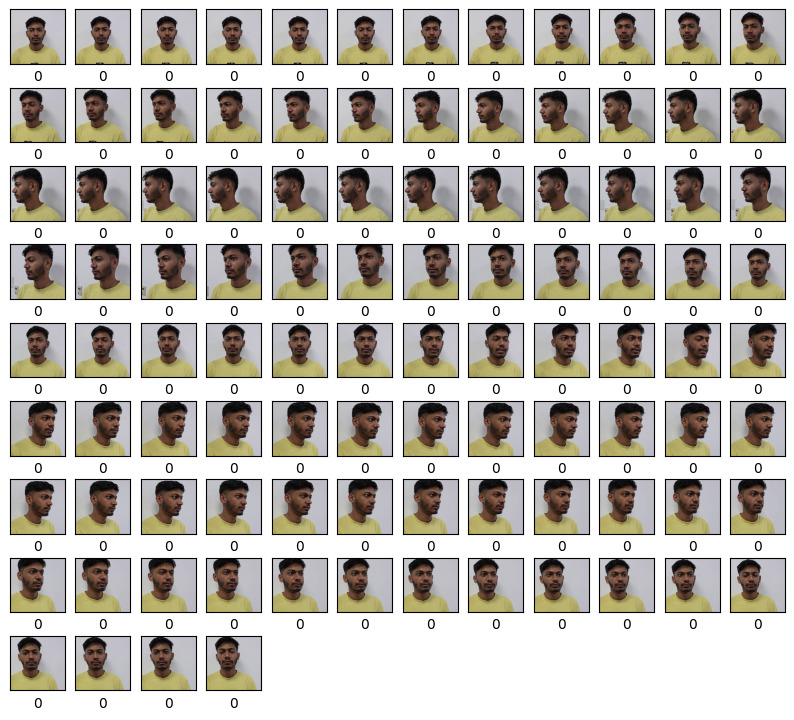

In [25]:
plt.figure(figsize=(10,10))
i = 0
for r in range(10):
    for c in range(10):
        plt.subplot(10, 12, i + 1)
        plt.imshow(data[i][0])
        plt.xticks([])
        plt.yticks([])
        plt.xlabel(data[i][1])
        i += 1
plt.show()

In [26]:
np.random.shuffle(data)

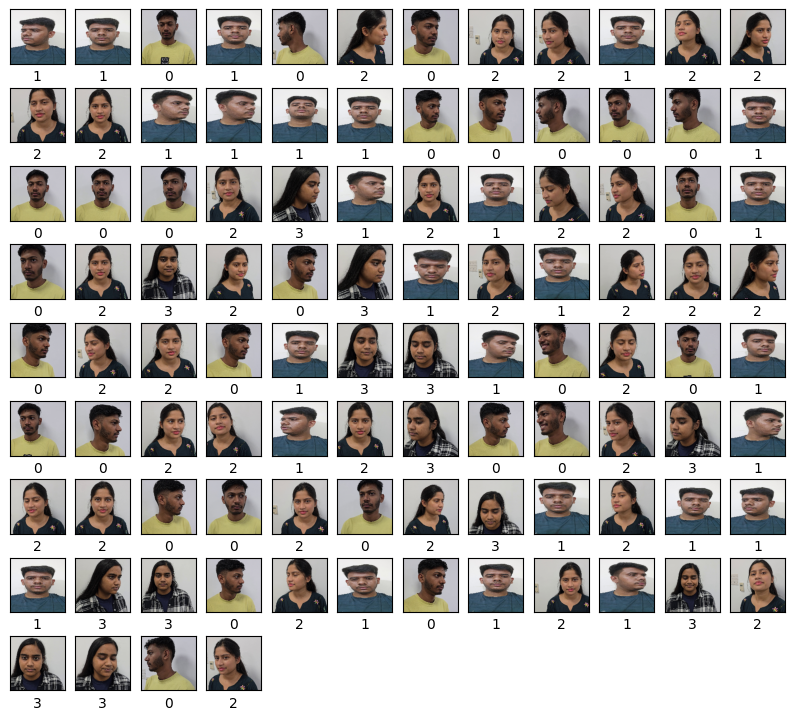

In [27]:
plt.figure(figsize=(10,10))
i = 0
for r in range(10):
    for c in range(10):
        plt.subplot(10, 12, i + 1)
        plt.imshow(data[i][0])
        plt.xticks([])
        plt.yticks([])
        plt.xlabel(data[i][1])
        i += 1
plt.show()

In [28]:
X, y = zip(*data)
X = np.array(X, dtype=np.float32)
y = np.array(y)
y_cat = to_categorical(y, num_classes=len(classes))


In [29]:
X_train, X_val, y_train, y_val = train_test_split(X, y_cat, test_size=0.2, random_state=42)


In [30]:
train_datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True,
    fill_mode='nearest'
)


In [31]:
val_datagen = ImageDataGenerator() 

In [32]:
train_generator = train_datagen.flow(X_train, y_train, batch_size=32)
val_generator = val_datagen.flow(X_val, y_val, batch_size=32)


In [33]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(image_size, image_size, 3)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.4),
    Dense(128, activation='relu'),
    Dense(len(classes), activation='softmax')
])

In [34]:
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_6 (Conv2D)           (None, 126, 126, 32)      896       
                                                                 
 batch_normalization_6 (Batc  (None, 126, 126, 32)     128       
 hNormalization)                                                 
                                                                 
 max_pooling2d_6 (MaxPooling  (None, 63, 63, 32)       0         
 2D)                                                             
                                                                 
 conv2d_7 (Conv2D)           (None, 61, 61, 64)        18496     
                                                                 
 batch_normalization_7 (Batc  (None, 61, 61, 64)       256       
 hNormalization)                                                 
                                                      

In [35]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=50
)


Epoch 1/50
35/35 [==============================] - 13s 128ms/step - loss: 1.4004 - accuracy: 0.8661 - val_loss: 18.6932 - val_accuracy: 0.2429
Epoch 2/50
35/35 [==============================] - 4s 103ms/step - loss: 0.1549 - accuracy: 0.9795 - val_loss: 45.7581 - val_accuracy: 0.2429
Epoch 3/50
35/35 [==============================] - 4s 104ms/step - loss: 0.1277 - accuracy: 0.9875 - val_loss: 73.0305 - val_accuracy: 0.2429
Epoch 4/50
35/35 [==============================] - 4s 103ms/step - loss: 0.0840 - accuracy: 0.9884 - val_loss: 63.9975 - val_accuracy: 0.2429
Epoch 5/50
35/35 [==============================] - 4s 99ms/step - loss: 0.0525 - accuracy: 0.9911 - val_loss: 64.7728 - val_accuracy: 0.2429
Epoch 6/50
35/35 [==============================] - 4s 105ms/step - loss: 0.1556 - accuracy: 0.9839 - val_loss: 68.6199 - val_accuracy: 0.2429
Epoch 7/50
35/35 [==============================] - 4s 108ms/step - loss: 0.0528 - accuracy: 0.9946 - val_loss: 64.1677 - val_accuracy: 0.2429

In [36]:
model.save("faceRecoginition_custom.h5")

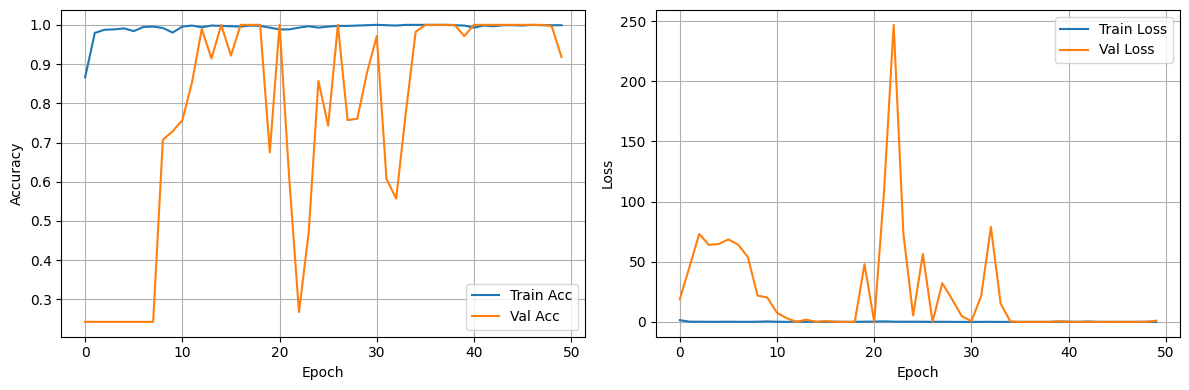

In [37]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()